# Decision Tree — and How It Compares to SVM

A **Decision Tree** classifies by asking a series of simple yes/no questions about the features — *"Is `thalach` above 150? Is `ca` greater than 0?"* — splitting the data at each step until it reaches a decision. The result is a flowchart you can literally read.

We'll use the same **Heart Disease** dataset as the SVM notebook so we can compare the two models head-to-head. The plan:
1. Train an **SVM** and print its classification report (our baseline).
2. Train a **Decision Tree** and see how it stacks up.

Two things to watch for, because they're where trees differ most from SVM:
- Trees **don't need feature scaling** (they split on thresholds, so the scale of a column doesn't matter).
- Trees **overfit easily** if you let them grow without limit.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load and clean (same as the SVM notebook): '?' -> NaN, drop the few missing rows
df = pd.read_csv('heart_disease.csv', na_values='?').dropna()
df['target'] = (df['num'] > 0).astype(int)   # 1 = has disease, 0 = healthy

X = df.drop(columns=['num', 'target'])   # the 13 features
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print('train:', X_train.shape[0], ' test:', X_test.shape[0])

train: 237  test: 60


## Part 1 — SVM baseline

SVM is distance-based, so we **scale** the features first (fit the scaler on the training data only), then train `SVC` and print the classification report.

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

svm = SVC(kernel='rbf')
svm.fit(X_train_s, y_train)

print('SVM accuracy:', round(svm.score(X_test_s, y_test), 3))
print(classification_report(y_test, svm.predict(X_test_s),
                            target_names=['no disease', 'disease']))

SVM accuracy: 0.85
              precision    recall  f1-score   support

  no disease       0.83      0.91      0.87        32
     disease       0.88      0.79      0.83        28

    accuracy                           0.85        60
   macro avg       0.85      0.85      0.85        60
weighted avg       0.85      0.85      0.85        60



The SVM lands around **85% accuracy** with solid recall on the `disease` class. That's the number our decision tree needs to beat.

## Part 2 — Decision Tree

Now the tree. Notice what we *don't* do: **no scaling**. A tree asks questions like *"is cholesterol > 240?"* — rescaling the numbers wouldn't change which side of the split a patient falls on, so it's simply unnecessary. We train straight on the raw features.

In [3]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(random_state=42)   # default: grow until pure
tree.fit(X_train, y_train)

print('Decision Tree — train accuracy:', round(tree.score(X_train, y_train), 3))
print('Decision Tree — test accuracy: ', round(tree.score(X_test, y_test), 3))
print(classification_report(y_test, tree.predict(X_test),
                            target_names=['no disease', 'disease']))

Decision Tree — train accuracy: 1.0
Decision Tree — test accuracy:  0.7
              precision    recall  f1-score   support

  no disease       0.71      0.75      0.73        32
     disease       0.69      0.64      0.67        28

    accuracy                           0.70        60
   macro avg       0.70      0.70      0.70        60
weighted avg       0.70      0.70      0.70        60



Look at those two numbers: **training accuracy is 1.0**, but **test accuracy is much lower** (~0.70) — and worse than the SVM. This is textbook **overfitting**. Left unchecked, a decision tree keeps splitting until every training point sits in its own little leaf, so it *memorizes* the training set (including its noise) instead of learning the general pattern.

### Fixing it: limit the tree's depth

The cure is to stop the tree from growing too deep. `max_depth` caps how many questions it can ask — a smaller tree is forced to keep only the *most useful* splits and generalizes better.

In [4]:
tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree.fit(X_train, y_train)

print('Decision Tree (max_depth=3) — train accuracy:', round(tree.score(X_train, y_train), 3))
print('Decision Tree (max_depth=3) — test accuracy: ', round(tree.score(X_test, y_test), 3))
print(classification_report(y_test, tree.predict(X_test),
                            target_names=['no disease', 'disease']))

Decision Tree (max_depth=3) — train accuracy: 0.844
Decision Tree (max_depth=3) — test accuracy:  0.8
              precision    recall  f1-score   support

  no disease       0.81      0.81      0.81        32
     disease       0.79      0.79      0.79        28

    accuracy                           0.80        60
   macro avg       0.80      0.80      0.80        60
weighted avg       0.80      0.80      0.80        60



Much better. The gap between train and test accuracy has shrunk, and **test accuracy jumps from ~0.70 to ~0.80** — a simpler tree actually generalizes *better*. It's now in the same ballpark as the SVM, and comes with a big bonus: we can read exactly how it decides.

### Reading the tree

This is the decision tree's superpower — unlike the SVM's abstract boundary, we can draw the whole flowchart. Each box shows the question, how many samples reached it, and which class it leans toward.

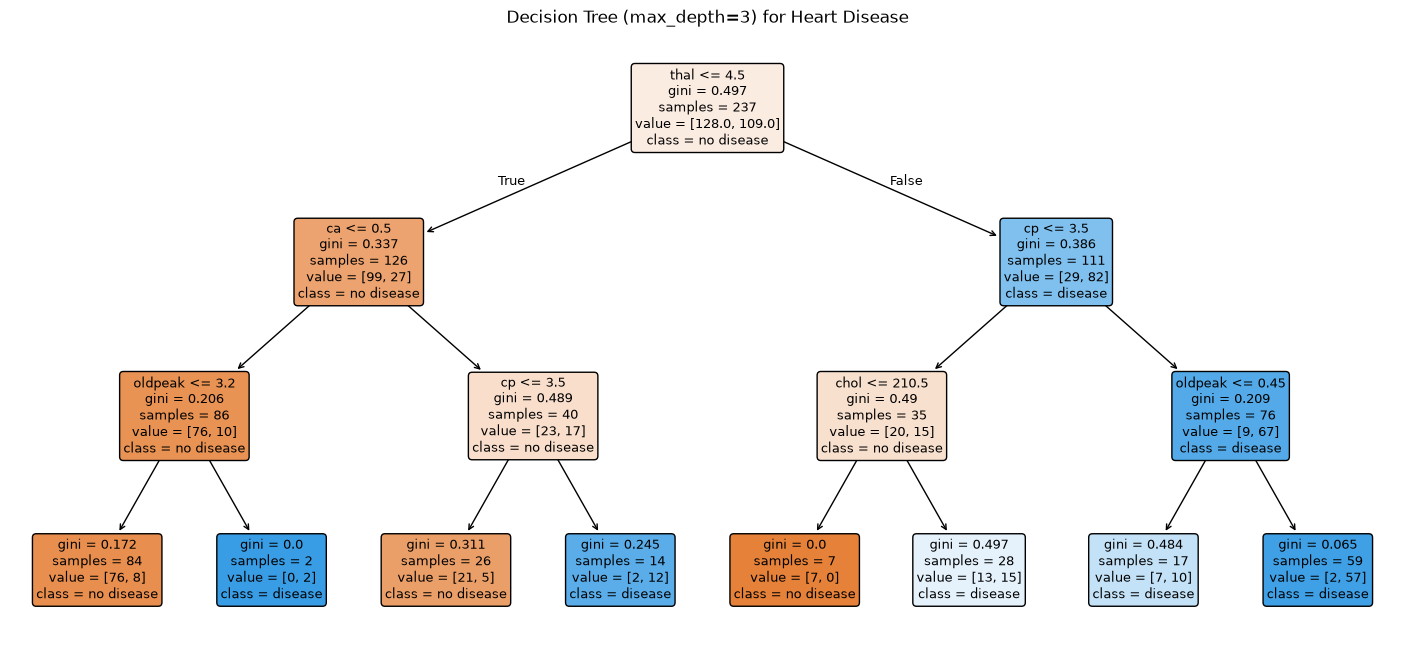

In [5]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 8))
plot_tree(tree, feature_names=X.columns, class_names=['no disease', 'disease'],
          filled=True, rounded=True, fontsize=9)
plt.title('Decision Tree (max_depth=3) for Heart Disease')
plt.show()

### Which features mattered most?

A tree also tells us how important each feature was — how much each one helped separate the classes across all its splits.

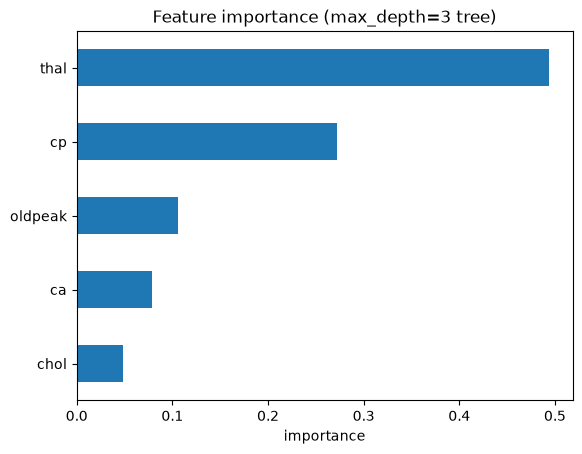

In [6]:
importances = pd.Series(tree.feature_importances_, index=X.columns)
importances = importances[importances > 0].sort_values()

importances.plot(kind='barh')
plt.xlabel('importance')
plt.title('Feature importance (max_depth=3 tree)')
plt.show()

## What we learned

| | **SVM** | **Decision Tree** |
|---|---|---|
| Needs feature scaling? | **Yes** (distance-based) | **No** (threshold splits) |
| Interpretable? | Hard — abstract boundary | **Easy** — read the flowchart |
| Overfitting risk | Controlled by `C`, `gamma` | **High** by default — cap with `max_depth` etc. |
| Accuracy here | ~0.85 | ~0.80 (after limiting depth) |

**Takeaways:**
- A **default decision tree overfits** — it grows until it memorizes the training data (train accuracy 1.0). Always limit its size (`max_depth`, `min_samples_leaf`, ...).
- Trees are wonderfully **interpretable** — you can show a doctor the exact questions the model asks.
- On this dataset the SVM edged out the tree on accuracy, but the tree is far easier to explain — a very common real-world trade-off.

**Try next:**
- Tune `max_depth` / `min_samples_leaf` with `GridSearchCV`.
- Train a **Random Forest** (many trees voting together) — it usually beats a single tree and often rivals the SVM.